In [1]:
import json
from itertools import combinations
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import mujoco as mj
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu

from ariel.body_phenotypes.robogen_lite.constructor import construct_mjspec_from_graph
from ariel.simulation.environments import SimpleFlatWorld
from ariel.utils.renderers import single_frame_renderer
from ea_body import genotype_to_graph, load_targets

HERE = Path.cwd()
DATA = HERE.parents[1] / "__data__" / "A1"
OUT = HERE / "results"
OUT.mkdir(exist_ok=True)
assert DATA.exists(), f"no experiment data at {DATA}"

sns.set_theme(style="whitegrid", font_scale=1.05)
mpl.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "lightgrey",
    "grid.alpha": 0.3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
})

CONFIGS = ["point", "subtree", "random"]
LABELS = {"point": "P (point)", "subtree": "S (subtree)", "random": "RS (random search)"}
SHORT = {"point": "P", "subtree": "S", "random": "RS"}
COLORS = {"point": "#2166ac", "subtree": "#d6604d", "random": "#4d4d4d", "target": "grey"}
H2_GEN = 10

In [2]:
frames = []
for config in CONFIGS:
    for f in sorted((DATA / config).glob("seed_*/generations.csv")):
        run = pd.read_csv(f)
        run["config"] = config
        run["seed"] = int(f.parent.name.split("_")[1])
        frames.append(run)
df = pd.concat(frames, ignore_index=True)

last = df.groupby(["config", "seed"]).tail(1)
assert last["gen"].nunique() == 1 and last["evals"].nunique() == 1, "incomplete or unequal runs"
last.groupby("config").agg(runs=("seed", "size"), last_gen=("gen", "first"), evals=("evals", "first")).reindex(CONFIGS)

,runs,last_gen,evals
config,,,
point,20,100,10100
subtree,20,100,10100
random,20,100,10100


In [3]:
final = last.set_index(["config", "seed"])["best"]
summary = final.groupby("config").agg(
    n="size",
    mean="mean",
    std="std",
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    min="min",
    max="max",
).reindex(CONFIGS)
summary.to_csv(OUT / "final_best.csv")
summary.round(3)

,n,mean,std,median,q1,q3,min,max
config,,,,,,,,
point,20,13.533,0.346,13.490,13.310,13.719,12.719,14.165
subtree,20,12.340,0.393,12.300,12.034,12.551,11.774,13.302
random,20,14.294,0.205,14.284,14.250,14.406,13.641,14.588


In [4]:
def a12(x, y):
    x = np.asarray(x, dtype=float)[:, None]
    y = np.asarray(y, dtype=float)[None, :]
    return float(((x < y).sum() + 0.5 * (x == y).sum()) / (x.size * y.size))


def holm(p):
    p = np.asarray(p, dtype=float)
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, i in enumerate(np.argsort(p, kind="stable")):
        running = max(running, min(1.0, (len(p) - rank) * p[i]))
        adjusted[i] = running
    return adjusted


assert a12([1, 2, 3], [4, 5, 6]) == 1.0 and a12([1], [1, 2]) == 0.75
assert np.allclose(holm([0.01, 0.04, 0.03]), [0.03, 0.06, 0.06])

rows = []
for x, y in combinations(CONFIGS, 2):
    res = mannwhitneyu(final.loc[x], final.loc[y], alternative="two-sided")
    rows.append({"test": "final best", "X": SHORT[x], "Y": SHORT[y], "U": res.statistic,
                 "p": res.pvalue, "A12 P(X<Y)": a12(final.loc[x], final.loc[y])})
tests = pd.DataFrame(rows)
tests["p_holm"] = holm(tests["p"])

at_h2 = df[df["gen"] == H2_GEN].set_index(["config", "seed"])["best"]
res = mannwhitneyu(at_h2.loc["point"], at_h2.loc["subtree"], alternative="two-sided")
tests.loc[len(tests)] = {"test": f"best at gen {H2_GEN}", "X": "P", "Y": "S", "U": res.statistic,
                         "p": res.pvalue, "A12 P(X<Y)": a12(at_h2.loc["point"], at_h2.loc["subtree"]),
                         "p_holm": np.nan}
tests.to_csv(OUT / "tests.csv", index=False)
tests

,test,X,Y,U,p,A12 P(X<Y),p_holm
0,final best,P,S,394.0,1.648290e-07,0.0150,3.296581e-07
1,final best,P,RS,9.0,2.556344e-07,0.9775,3.296581e-07
2,final best,S,RS,0.0,6.757379e-08,1.0000,2.027214e-07
3,best at gen 10,P,S,276.0,4.112359e-02,0.3100,NaN


In [5]:
ea = df[(df["config"] != "random") & (df["gen"] > 0)]
guard = ea.groupby("config")[["size_rejections", "size_fallbacks"]].sum().astype(int)
start = df[df["gen"] == 0].set_index(["config", "seed"])["evals"]
end = last.set_index(["config", "seed"])["evals"]
guard["offspring"] = (end - start).groupby("config").sum()
guard.to_csv(OUT / "size_guard.csv")
guard

,size_rejections,size_fallbacks,offspring
config,,,
point,0,0,200000
subtree,3,0,200000


In [6]:
pd.read_csv(OUT / "step_size.csv").round(3)

,parents,operator,n,mean_abs_d_nodes,mean_abs_d_fitness,median_abs_d_fitness,noop_rate,growth_rate,shrink_rate,over_cap_rate
0,ramped,replace_node (P),1000,0.783,0.440,0.283,0.000,0.000,0.276,0.000
1,ramped,subtree_replacement (S),1000,1.297,0.521,0.336,0.060,0.199,0.348,0.012
2,ramped,shrink,1000,1.208,0.459,0.249,0.100,0.000,0.437,0.000
3,ramped,hoist,1000,1.854,0.629,0.482,0.088,0.000,0.912,0.000
4,full21,replace_node (P),1000,1.308,0.713,0.346,0.000,0.000,0.336,0.000
5,full21,subtree_replacement (S),1000,2.138,1.021,0.578,0.074,0.197,0.424,0.197
6,full21,shrink,1000,1.955,0.894,0.385,0.085,0.000,0.491,0.000
7,full21,hoist,1000,2.752,1.253,0.879,0.000,0.000,1.000,0.000


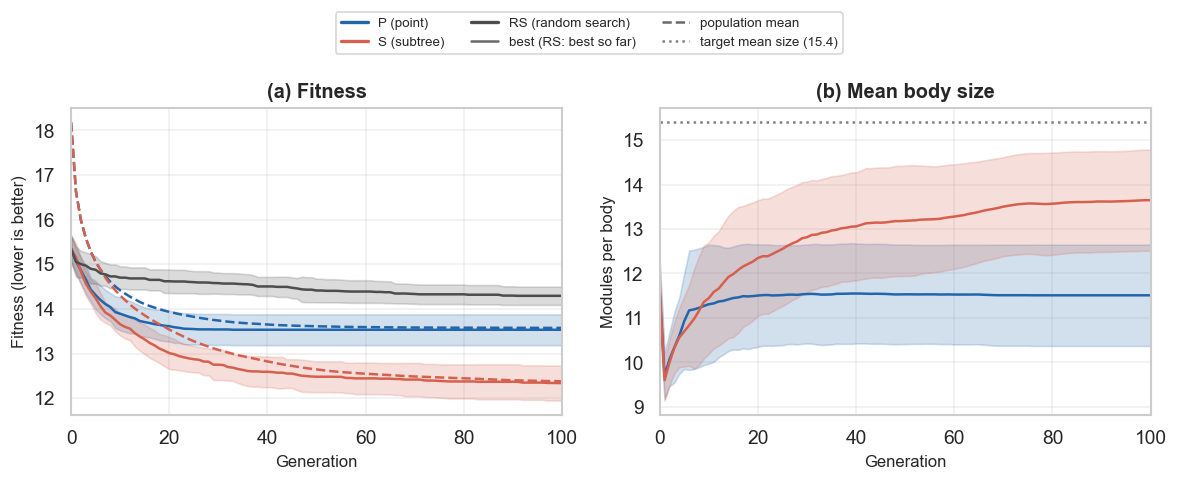

In [7]:
target_mean = np.mean([t.number_of_nodes() for t in load_targets()])

fig, (ax_fit, ax_size) = plt.subplots(1, 2, figsize=(10, 3.6))
for config in CONFIGS:
    runs = df[df["config"] == config]
    sns.lineplot(data=runs, x="gen", y="best", color=COLORS[config], errorbar="sd",
                 legend=False, ax=ax_fit)
    if config != "random":
        sns.lineplot(data=runs, x="gen", y="mean", color=COLORS[config], errorbar=None,
                     linestyle="--", legend=False, ax=ax_fit)
        sns.lineplot(data=runs, x="gen", y="mean_size", color=COLORS[config], errorbar="sd",
                     legend=False, ax=ax_size)
ax_size.axhline(target_mean, color=COLORS["target"], linestyle=":")

ax_fit.set(title="(a) Fitness", xlabel="Generation", ylabel="Fitness (lower is better)")
ax_size.set(title="(b) Mean body size", xlabel="Generation", ylabel="Modules per body")
for ax in (ax_fit, ax_size):
    ax.set_xlim(0, df["gen"].max())

handles = [Line2D([], [], color=COLORS[c], lw=2) for c in CONFIGS]
handles += [Line2D([], [], color="dimgrey", ls="-"), Line2D([], [], color="dimgrey", ls="--"),
            Line2D([], [], color=COLORS["target"], ls=":")]
labels = [LABELS[c] for c in CONFIGS]
labels += ["best (RS: best so far)", "population mean", f"target mean size ({target_mean:.1f})"]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
fig.tight_layout()
fig.savefig(OUT / "fig1_dynamics.png")
fig.savefig(OUT / "fig1_dynamics.pdf")
plt.show()

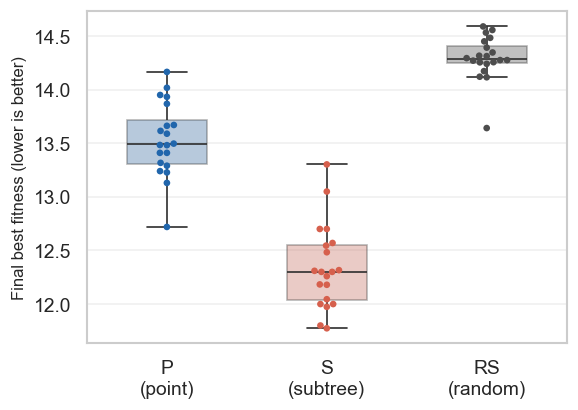

In [8]:
order = [f"{SHORT[c]}\n({c})" for c in CONFIGS]
palette = {label: COLORS[c] for label, c in zip(order, CONFIGS)}
final_df = last.assign(label=last["config"].map(lambda c: f"{SHORT[c]}\n({c})"))

fig, ax = plt.subplots(figsize=(5, 3.6))
sns.boxplot(data=final_df, x="label", y="best", hue="label", order=order, palette=palette,
            width=0.5, showfliers=False, boxprops={"alpha": 0.35}, legend=False, ax=ax)
sns.swarmplot(data=final_df, x="label", y="best", hue="label", order=order, palette=palette,
              size=4, legend=False, ax=ax)
ax.set(xlabel="", ylabel="Final best fitness (lower is better)")
fig.tight_layout()
fig.savefig(OUT / "fig2_final_best.png")
fig.savefig(OUT / "fig2_final_best.pdf")
plt.show()

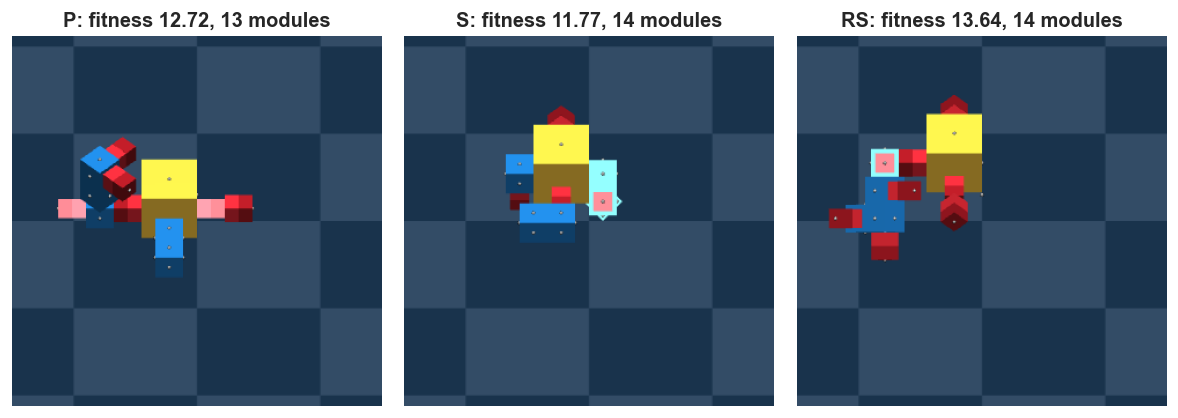

In [9]:
best_runs = last.loc[last.groupby("config")["best"].idxmin()].set_index("config").reindex(CONFIGS)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, (config, row) in zip(axes, best_runs.iterrows()):
    payload = json.loads((DATA / config / f"seed_{int(row['seed']):02d}" / "best_genome.json").read_text())
    mj.set_mjcb_control(None)
    world = SimpleFlatWorld()
    robot = construct_mjspec_from_graph(genotype_to_graph(payload["genotype"]))
    world.spawn(robot.spec, position=[0.0, 0.0, 0.1], correct_collision_with_floor=True)
    model = world.spec.compile()
    data = mj.MjData(model)
    mj.mj_forward(model, data)
    image = single_frame_renderer(model, data, width=640, height=640, cam_fovy=2.0,
                                  save=True, save_path=str(OUT / f"best_body_{config}.png"))
    w, h = image.size
    ax.imshow(image.crop((w * 0.25, h * 0.25, w * 0.75, h * 0.75)))
    ax.set_title(f"{SHORT[config]}: fitness {row['best']:.2f}, {payload['num_nodes']} modules")
    ax.axis("off")
fig.tight_layout()
fig.savefig(OUT / "fig3_best_bodies.png")
fig.savefig(OUT / "fig3_best_bodies.pdf")
plt.show()